#HW 5: Selection Problem
- Find ith order statistic of an input array
- i is chosen from 1, 2, ..., n, where n is the total number of elements in the input array

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import random

##Naive Implementation using sorting
- Apply MergeSort

In [2]:
def NSelect(array, i):
    B = MergeSort(array)
    return B[i-1]

def MergeSort(array):
    if len(array) == 1:
        return array
    else:
        left = MergeSort(array[:len(array)//2])
        right = MergeSort(array[len(array)//2:])
        return Merge(left, right)

def Merge(left, right):
    result = []
    i = 0
    j = 0
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    while i < len(left):
        result.append(left[i])
        i += 1

    while j < len(right):
        result.append(right[j])
        j += 1

    return result


In [3]:
# Quick test on some input arrays
testCases = [[1, 2, 3, 4, 5],
             [2, 1, 4, 3, 5],
             [3, 2, 1, 5, 4],
             [5, 4, 3, 2, 1],
             [3, 3, 5, 1, 2]]

for testCase in testCases:
    print(testCase)
    print(NSelect(testCase, 3))

[1, 2, 3, 4, 5]
3
[2, 1, 4, 3, 5]
3
[3, 2, 1, 5, 4]
3
[5, 4, 3, 2, 1]
3
[3, 3, 5, 1, 2]
3


##RSelect Algorithm
- Refer to Section 6.1

In [20]:
def RSelect(array, l, r, i):
    if l == r:
        return array[l]

    pivot_idx = random.randint(l, r)
    array[pivot_idx], array[r] = array[r], array[pivot_idx]
    pivot = Partition(array, l, r)
    rank = pivot - l + 1

    if i == rank:
        return array[pivot]
    elif i < rank:
        return RSelect(array, l, pivot - 1, i)
    else:
        return RSelect(array, pivot + 1, r, i - rank)

def Partition(array, l, r):
    pivot = array[r]
    i = l

    for j in range(l, r):
        if array[j] <= pivot:
            array[i], array[j] = array[j], array[i]
            i += 1

    array[i], array[r] = array[r], array[i]
    return i

In [21]:
# Quick test on some input arrays
testCases = [[1, 2, 3, 4, 5],
             [2, 1, 4, 3, 5],
             [3, 2, 1, 5, 4],
             [5, 4, 3, 2, 1],
             [3, 3, 5, 1, 2]]

for testCase in testCases:
    print(testCase)
    print(RSelect(testCase, 0, len(testCase)-1, 3))

[1, 2, 3, 4, 5]
3
[2, 1, 4, 3, 5]
3
[3, 2, 1, 5, 4]
3
[5, 4, 3, 2, 1]
3
[3, 3, 5, 1, 2]
3


##Compare two algorithms for selection problem  

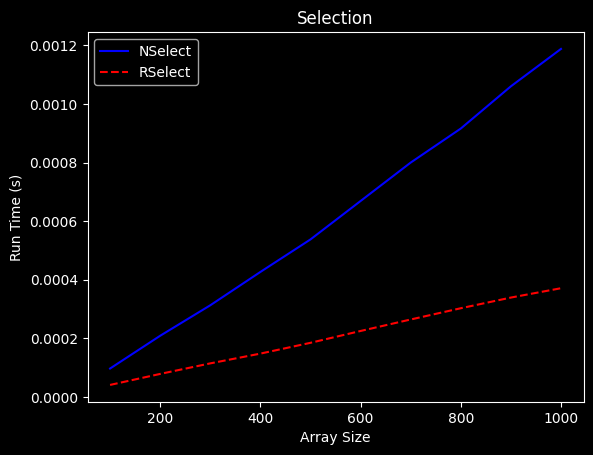

In [22]:
maxNumber = 20000
startArraySize = 100
endArraySize = 1000
stepArraySize = 100
runsPerSize = 1000

# Generate a random array of a given size
def GenerateRandomArray(size):
    return np.random.randint(0, maxNumber, size)

averageRunTimesNSelect = []
averageRunTimesRSelect = []

np.random.seed(42)

for arraySize in range(startArraySize, endArraySize+1, stepArraySize):
    runTimesNSelect = []
    runTimesRSelect = []

    for run in range(runsPerSize):
        array = GenerateRandomArray(arraySize)
        backup_array = array.copy()
        order = random.randint(1, arraySize)

        start = time.time()
        resultNSelect = NSelect(array, order)
        end = time.time()
        runTimesNSelect.append(end-start)

        start = time.time()
        resultRSelect = RSelect(array, 0, len(array)-1, order)
        end = time.time()
        runTimesRSelect.append(end-start)

        if resultNSelect != resultRSelect:
            print("Error: results do not match")
            print("Array: ", backup_array)
            print("Order: ", order)
            print("NSelect: ", resultNSelect)
            print("RSelect: ", resultRSelect)
            break

    averageRunTimesNSelect.append(np.mean(runTimesNSelect))
    averageRunTimesRSelect.append(np.mean(runTimesRSelect))

x = np.arange(startArraySize, endArraySize+1, stepArraySize)
plt.plot(x, averageRunTimesNSelect, 'b', label='NSelect')
plt.plot(x, averageRunTimesRSelect, 'r--', label='RSelect')
plt.title('Selection')
plt.xlabel('Array Size')
plt.ylabel('Run Time (s)')
plt.legend()
plt.show()
